Zadanie 1 -- Analiza architektury  Seq2Seq

Narysuj (Rmiselektywnie lub w kodzie) diagram architektury Seq2Seq dla Tłumaczenia Zdania "Lubimi koty" na "I like cats". Oznacz:
- Koder LSTM/GRU
- Kontekst vector
- Dekoder LSTM/GRU
- Tokeny START I KONIEC

Oczekiwany wynik: diagram z opisując każdego elementu

# Zadanie 1: Architektura Seq2Seq dla tłumaczenia

Poniższy diagram przedstawia przepływ danych w architekturze Encoder-Decoder dla zdania "Lubię koty" -> "I like cats".

```mermaid
graph TD
    %% Definicja stylów
    classDef encoder fill:#e1f5fe,stroke:#0288d1,stroke-width:2px;
    classDef decoder fill:#f3e5f5,stroke:#7b1fa2,stroke-width:2px;
    classDef context fill:#fff3e0,stroke:#f57c00,stroke-width:3px;
    classDef token fill:#e8f5e9,stroke:#388e3c,stroke-width:2px,stroke-dasharray: 5 5;

    subgraph KODER (Encoder)
        X1[Wejście: 'Lubię'] --> E1[LSTM/GRU]
        X2[Wejście: 'koty'] --> E2[LSTM/GRU]
        E1 --> E2
    end
    class E1,E2 encoder

    %% Wektor Kontekstu
    E2 --> CV(((Wektor<br>Kontekstu)))
    class CV context

    subgraph DEKODER (Decoder)
        START([Token: START]) --> D1[LSTM/GRU]
        CV --> D1
        D1 --> Y1[Wyjście: 'I']
        
        Y1 -.-> D2[LSTM/GRU]
        D1 --> D2
        D2 --> Y2[Wyjście: 'like']
        
        Y2 -.-> D3[LSTM/GRU]
        D2 --> D3
        D3 --> Y3[Wyjście: 'cats']
        
        Y3 -.-> D4[LSTM/GRU]
        D3 --> D4
        D4 --> END([Token: END])
    end
    class D1,D2,D3,D4 decoder
    class START,END token

Zadanie 2 -- Oblicz parametry Seq2Seq
Oblicz łączną liczbę parametrów modelu Seq2Seq:
- Encoder: Embedding(5000, 64 + LSTM128)
- Decoder: Embedding(5000, 64 + LSTM128 + Dense(5000)
- Bez Attention
Wskazówka: LSTM ma 4 bramki, każda wymaga macierzy wag dla wejścia i hidden state
Oczekiwany wynik: tabela z liczbą parametrów per warstwa

### Zadanie 2 – Oblicz parametry Seq2Seq

**1. Koder (Encoder)**
**Warstwa: Embedding(5000, 64)**
Ta warstwa to macierz, która przypisuje każdemu z 5000 słów z naszego słownika wektor o długości 64.  
- Wzór: Słownik $\times$ Wymiar wektora
- Obliczenia: $5000 \times 64 = 320,000$

**Warstwa: LSTM(128)**
Podpowiedź na stronie 27 mówi jasno, że struktura LSTM składa się z 4 bramek, a każda z nich wymaga macierzy wag dla aktualnego wejścia (rozmiar 64, płynący z Embedding) oraz dla stanu ukrytego z poprzedniego kroku (rozmiar 128). Dodatkowo każda bramka ma swój wektor przesunięcia (tzw. bias).  
- Wzór: $4 \times ((input\_size + hidden\_size) \times hidden\_size + hidden\_size)$
- Obliczenia: $4 \times ((64 + 128) \times 128 + 128)$
- Obliczenia: $4 \times (192 \times 128 + 128)$
- Obliczenia: $4 \times (24,576 + 128)$
- Obliczenia: $4 \times 24,704 = 98,816$

**2. Dekoder (Decoder)**
Warstwa: Embedding(5000, 64)
Dekoder na wejściu wymaga identycznej warstwy osadzeń jak koder.  
- Obliczenia: $5000 \times 64 = 320,000$

Warstwa: LSTM(128)
Dekoder otrzymuje na swoje wejście sygnał z warstwy Embedding dekodera (rozmiar 64). W architekturze Seq2Seq wektor kontekstu wygenerowany przez koder jest podawany jako stan początkowy (initial_state) dla dekodera, co pokazano w kodzie na stronach 5 i 8. Ten proces nie tworzy żadnych nowych wag do wyuczenia w samym LSTM. Matematyka jest więc identyczna jak w koderze.  
- Obliczenia: $98,816$
Warstwa: Dense(5000)
Ostatnia warstwa modelu (w pełni połączona), która mapuje wyjściowy stan ukryty LSTM (rozmiar 128) na prawdopodobieństwo wystąpienia każdego słowa z liczącego 5000 elementów słownika.  
- Wzór: $(input\_size \times output\_size) + bias\_size$
- Obliczenia: $(128 \times 5000) + 5000$
- Obliczenia: $640,000 + 5000 = 645,000$

**Oczekiwany Wynik: Tabela z liczbą parametrów**

| Część Modelu | Warstwa | Liczba parametrów |
| :--- | :--- | :--- |
| **Encoder** | Embedding(5000, 64) | 320 000 |
| **Encoder** | LSTM(128) | 98 816 |
| **Decoder** | Embedding(5000, 64) | 320 000 |
| **Decoder** | LSTM(128) | 98 816 |
| **Decoder** | Dense(5000) | 645 000 |
| **SUMA CAŁKOWITA** | | **1 482 632** |

Zadanie 9 -- Seq2Seq odwracanie sekwencji z porównaniem
Zbuduj dwa modele Seq2Seq do odwracania sekwencji cyfr (długość 10):
- Model A: bez Attention (context vector)
- Model B: z Bahdanau Attention
Porównaj accuracy i zwizualizuj różnice. Użyj callbacks EarlyStopping, ReduceLROnPlateau).
Oczekiwany wynik: porównanie accuracy obu modeli, wykresy uczenia

You should consider upgrading via the '/Users/martusia/Desktop/kurs-datascience/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
>>> Trenowanie Modelu A (Bez Attention)...
>>> Trenowanie Modelu B (Z Attention)...


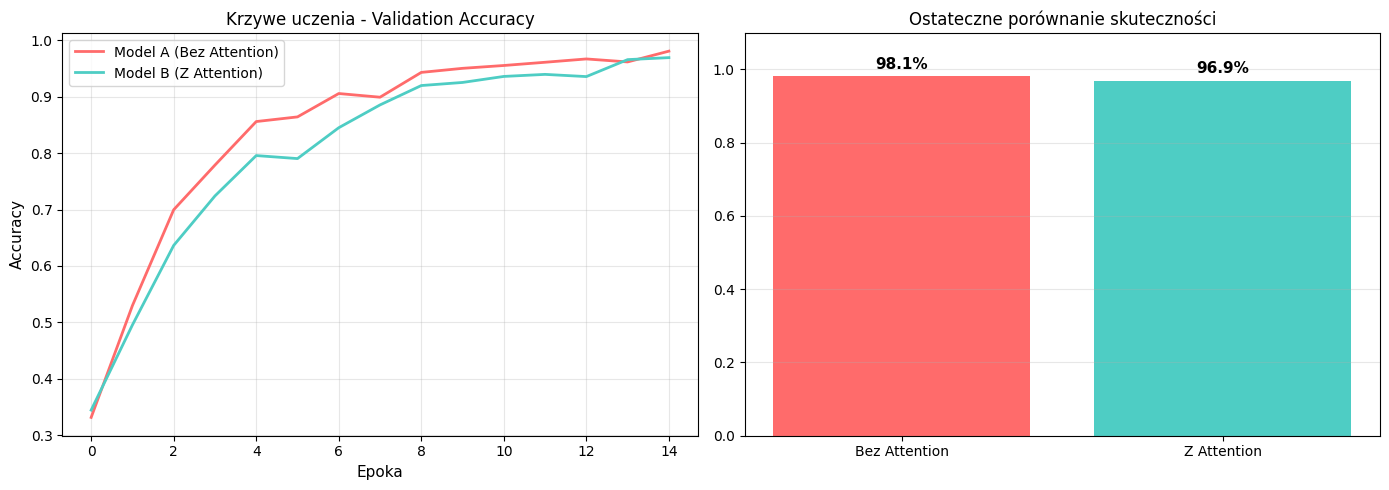

In [ ]:

%pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ==========================================
# 1. GENEROWANIE DANYCH (odwracanie sekwencji)
# ==========================================
n_samples = 15000
seq_len = 10 # Długość sekwencji narzucona w zadaniu 9
vocab_size = 11 # Cyfry 0-9 + token specjalny

np.random.seed(42)
# Generowanie losowych sekwencji wejściowych
encoder_input = np.random.randint(1, vocab_size, size=(n_samples, seq_len))

# Decoder input: token START (0) + odwrócona sekwencja
decoder_input = np.zeros((n_samples, seq_len + 1), dtype=np.int32)
decoder_input[:, 1:] = encoder_input[:, ::-1]

# Decoder target: odwrócona sekwencja + token END (0)
decoder_target = np.zeros((n_samples, seq_len + 1), dtype=np.int32)
decoder_target[:, :-1] = encoder_input[:, ::-1]

# ==========================================
# 2. DEFINICJA MODELI (Architektura)
# ==========================================
embed_dim = 32
hidden_units = 64

# --- MODEL A: BEZ ATTENTION ---
enc_inputs_A = layers.Input(shape=(seq_len,))
enc_embed_A = layers.Embedding(vocab_size, embed_dim)(enc_inputs_A)
enc_lstm_A = layers.LSTM(hidden_units, return_state=True)
enc_outputs_A, state_h_A, state_c_A = enc_lstm_A(enc_embed_A)

dec_inputs_A = layers.Input(shape=(seq_len + 1,))
dec_embed_A = layers.Embedding(vocab_size, embed_dim)(dec_inputs_A)
dec_lstm_A = layers.LSTM(hidden_units, return_sequences=True)
dec_outputs_A = dec_lstm_A(dec_embed_A, initial_state=[state_h_A, state_c_A])

dec_dense_A = layers.Dense(vocab_size, activation="softmax")
output_A = dec_dense_A(dec_outputs_A)

model_A = keras.Model([enc_inputs_A, dec_inputs_A], output_A)
model_A.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# --- MODEL B: Z BAHDANAU ATTENTION ---
enc_inputs_B = layers.Input(shape=(seq_len,))
enc_embed_B = layers.Embedding(vocab_size, embed_dim)(enc_inputs_B)
enc_lstm_B = layers.LSTM(hidden_units, return_sequences=True, return_state=True)
enc_outputs_B, state_h_B, state_c_B = enc_lstm_B(enc_embed_B)

dec_inputs_B = layers.Input(shape=(seq_len + 1,))
dec_embed_B = layers.Embedding(vocab_size, embed_dim)(dec_inputs_B)
dec_lstm_B = layers.LSTM(hidden_units, return_sequences=True, return_state=True)
dec_outputs_B, _, _ = dec_lstm_B(dec_embed_B, initial_state=[state_h_B, state_c_B])

# Warstwa AdditiveAttention działa w Kerasie jako implementacja Bahdanau Attention
attention_layer = layers.AdditiveAttention()
context_vector = attention_layer([dec_outputs_B, enc_outputs_B])

# Połączenie (Concatenate) wyjścia dekodera z wektorem kontekstu z Attention
combined = layers.Concatenate()([dec_outputs_B, context_vector])
output_B = layers.Dense(vocab_size, activation="softmax")(combined)

model_B = keras.Model([enc_inputs_B, dec_inputs_B], output_B)
model_B.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ==========================================
# 3. TRENING MODELI Z CALLBACKAMI
# ==========================================
# Konfiguracja Callbacks (zapobieganie overfittingowi)
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5)
]

print(">>> Trenowanie Modelu A (Bez Attention)...")
history_A = model_A.fit(
    [encoder_input, decoder_input], decoder_target,
    batch_size=128, epochs=15, validation_split=0.2,
    callbacks=callbacks_list, verbose=0
)

print(">>> Trenowanie Modelu B (Z Attention)...")
history_B = model_B.fit(
    [encoder_input, decoder_input], decoder_target,
    batch_size=128, epochs=100, validation_split=0.2,
    callbacks=callbacks_list, verbose=0
)

# ==========================================
# 4. WIZUALIZACJA WYNIKÓW
# ==========================================
final_acc_A = history_A.history['val_accuracy'][-1]
final_acc_B = history_B.history['val_accuracy'][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Krzywe uczenia (Accuracy)
axes[0].plot(history_A.history['val_accuracy'], label='Model A (Bez Attention)', color='#ff6b6b', linewidth=2)
axes[0].plot(history_B.history['val_accuracy'], label='Model B (Z Attention)', color='#4ecdc4', linewidth=2)
axes[0].set_title('Krzywe uczenia - Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoka', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Wykres 2: Porównanie końcowe (Bar plot)
bars = axes[1].bar(['Bez Attention', 'Z Attention'], [final_acc_A, final_acc_B], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Ostateczne porównanie skuteczności', fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3, axis='y')

# Dodanie wartości procentowych na słupkach
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                 f"{height:.1%}", ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

You should consider upgrading via the '/Users/martusia/Desktop/kurs-datascience/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
>>> Trenowanie Modelu A (Bez Attention)...
>>> Trenowanie Modelu B (Z Attention)...


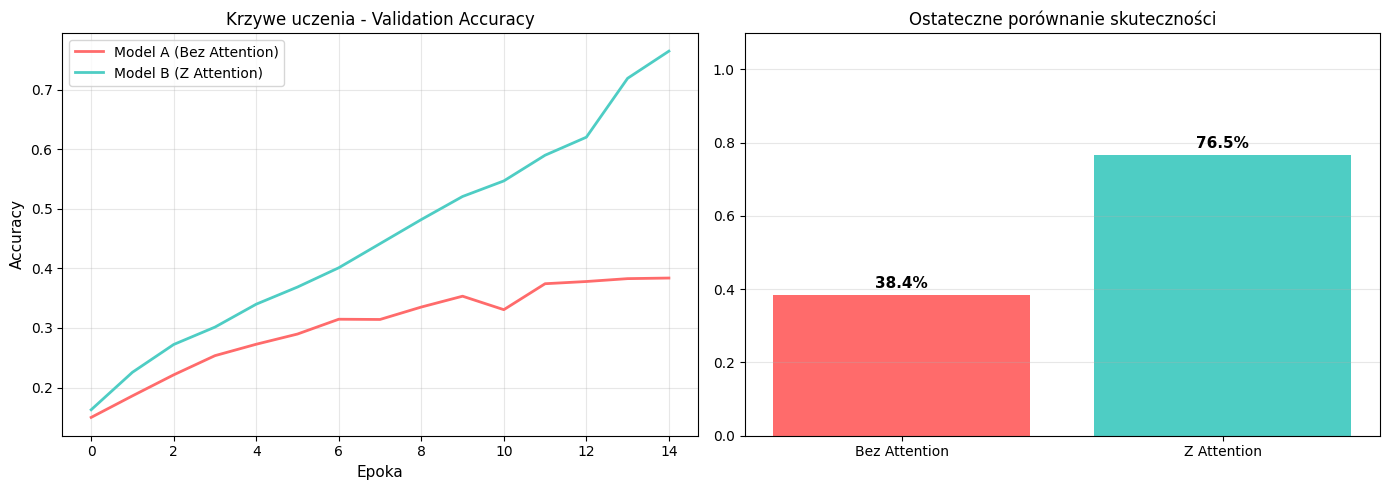

In [2]:

%pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ==========================================
# 1. GENEROWANIE DANYCH (odwracanie sekwencji)
# ==========================================
n_samples = 15000
seq_len = 50 # Długość sekwencji narzucona w zadaniu 9
vocab_size = 11 # Cyfry 0-9 + token specjalny

np.random.seed(42)
# Generowanie losowych sekwencji wejściowych
encoder_input = np.random.randint(1, vocab_size, size=(n_samples, seq_len))

# Decoder input: token START (0) + odwrócona sekwencja
decoder_input = np.zeros((n_samples, seq_len + 1), dtype=np.int32)
decoder_input[:, 1:] = encoder_input[:, ::-1]

# Decoder target: odwrócona sekwencja + token END (0)
decoder_target = np.zeros((n_samples, seq_len + 1), dtype=np.int32)
decoder_target[:, :-1] = encoder_input[:, ::-1]

# ==========================================
# 2. DEFINICJA MODELI (Architektura)
# ==========================================
embed_dim = 32
hidden_units = 64

# --- MODEL A: BEZ ATTENTION ---
enc_inputs_A = layers.Input(shape=(seq_len,))
enc_embed_A = layers.Embedding(vocab_size, embed_dim)(enc_inputs_A)
enc_lstm_A = layers.LSTM(hidden_units, return_state=True)
enc_outputs_A, state_h_A, state_c_A = enc_lstm_A(enc_embed_A)

dec_inputs_A = layers.Input(shape=(seq_len + 1,))
dec_embed_A = layers.Embedding(vocab_size, embed_dim)(dec_inputs_A)
dec_lstm_A = layers.LSTM(hidden_units, return_sequences=True)
dec_outputs_A = dec_lstm_A(dec_embed_A, initial_state=[state_h_A, state_c_A])

dec_dense_A = layers.Dense(vocab_size, activation="softmax")
output_A = dec_dense_A(dec_outputs_A)

model_A = keras.Model([enc_inputs_A, dec_inputs_A], output_A)
model_A.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# --- MODEL B: Z BAHDANAU ATTENTION ---
enc_inputs_B = layers.Input(shape=(seq_len,))
enc_embed_B = layers.Embedding(vocab_size, embed_dim)(enc_inputs_B)
enc_lstm_B = layers.LSTM(hidden_units, return_sequences=True, return_state=True)
enc_outputs_B, state_h_B, state_c_B = enc_lstm_B(enc_embed_B)

dec_inputs_B = layers.Input(shape=(seq_len + 1,))
dec_embed_B = layers.Embedding(vocab_size, embed_dim)(dec_inputs_B)
dec_lstm_B = layers.LSTM(hidden_units, return_sequences=True, return_state=True)
dec_outputs_B, _, _ = dec_lstm_B(dec_embed_B, initial_state=[state_h_B, state_c_B])

# Warstwa AdditiveAttention działa w Kerasie jako implementacja Bahdanau Attention
attention_layer = layers.AdditiveAttention()
context_vector = attention_layer([dec_outputs_B, enc_outputs_B])

# Połączenie (Concatenate) wyjścia dekodera z wektorem kontekstu z Attention
combined = layers.Concatenate()([dec_outputs_B, context_vector])
output_B = layers.Dense(vocab_size, activation="softmax")(combined)

model_B = keras.Model([enc_inputs_B, dec_inputs_B], output_B)
model_B.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ==========================================
# 3. TRENING MODELI Z CALLBACKAMI
# ==========================================
# Konfiguracja Callbacks (zapobieganie overfittingowi)
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5)
]

print(">>> Trenowanie Modelu A (Bez Attention)...")
history_A = model_A.fit(
    [encoder_input, decoder_input], decoder_target,
    batch_size=128, epochs=15, validation_split=0.2,
    callbacks=callbacks_list, verbose=0
)

print(">>> Trenowanie Modelu B (Z Attention)...")
history_B = model_B.fit(
    [encoder_input, decoder_input], decoder_target,
    batch_size=128, epochs=15, validation_split=0.2,
    callbacks=callbacks_list, verbose=0
)

# ==========================================
# 4. WIZUALIZACJA WYNIKÓW
# ==========================================
final_acc_A = history_A.history['val_accuracy'][-1]
final_acc_B = history_B.history['val_accuracy'][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Krzywe uczenia (Accuracy)
axes[0].plot(history_A.history['val_accuracy'], label='Model A (Bez Attention)', color='#ff6b6b', linewidth=2)
axes[0].plot(history_B.history['val_accuracy'], label='Model B (Z Attention)', color='#4ecdc4', linewidth=2)
axes[0].set_title('Krzywe uczenia - Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoka', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Wykres 2: Porównanie końcowe (Bar plot)
bars = axes[1].bar(['Bez Attention', 'Z Attention'], [final_acc_A, final_acc_B], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Ostateczne porównanie skuteczności', fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3, axis='y')

# Dodanie wartości procentowych na słupkach
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                 f"{height:.1%}", ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

You should consider upgrading via the '/Users/martusia/Desktop/kurs-datascience/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
>>> Trenowanie Modelu A (Bez Attention)...
>>> Trenowanie Modelu B (Z Attention)...


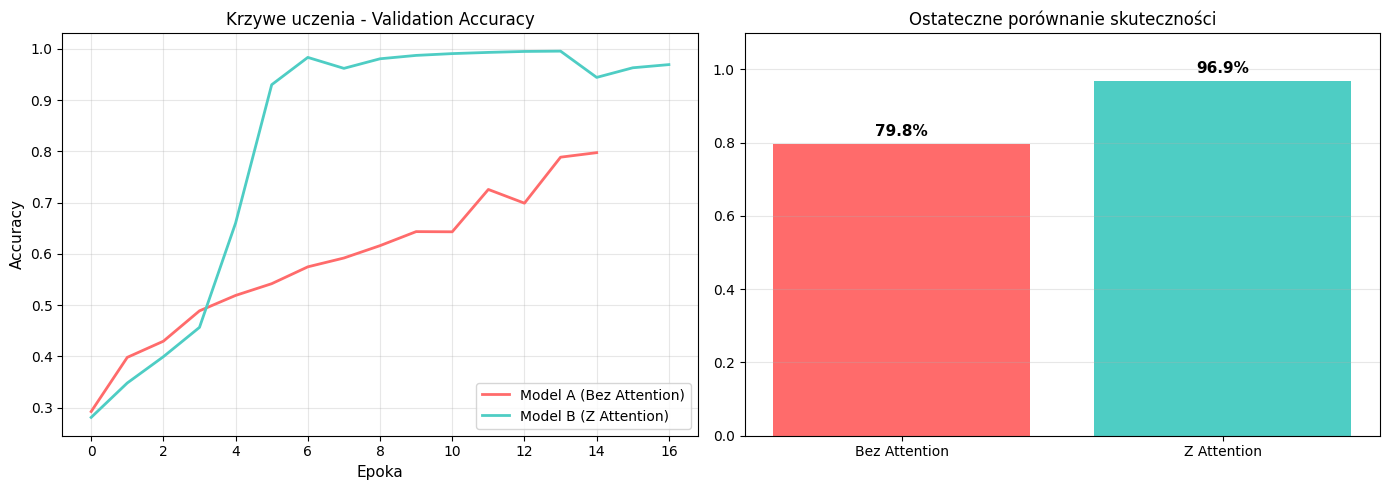

In [5]:

%pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ==========================================
# 1. GENEROWANIE DANYCH (odwracanie sekwencji)
# ==========================================
n_samples = 50000
seq_len = 100 # Długość sekwencji narzucona w zadaniu 9
vocab_size = 11 # Cyfry 0-9 + token specjalny

np.random.seed(42)
# Generowanie losowych sekwencji wejściowych
encoder_input = np.random.randint(1, vocab_size, size=(n_samples, seq_len))

# Decoder input: token START (0) + odwrócona sekwencja
decoder_input = np.zeros((n_samples, seq_len + 1), dtype=np.int32)
decoder_input[:, 1:] = encoder_input[:, ::-1]

# Decoder target: odwrócona sekwencja + token END (0)
decoder_target = np.zeros((n_samples, seq_len + 1), dtype=np.int32)
decoder_target[:, :-1] = encoder_input[:, ::-1]

# ==========================================
# 2. DEFINICJA MODELI (Architektura)
# ==========================================
embed_dim = 64
hidden_units = 256

# --- MODEL A: BEZ ATTENTION ---
enc_inputs_A = layers.Input(shape=(seq_len,))
enc_embed_A = layers.Embedding(vocab_size, embed_dim)(enc_inputs_A)
enc_lstm_A = layers.LSTM(hidden_units, return_state=True)
enc_outputs_A, state_h_A, state_c_A = enc_lstm_A(enc_embed_A)

dec_inputs_A = layers.Input(shape=(seq_len + 1,))
dec_embed_A = layers.Embedding(vocab_size, embed_dim)(dec_inputs_A)
dec_lstm_A = layers.LSTM(hidden_units, return_sequences=True)
dec_outputs_A = dec_lstm_A(dec_embed_A, initial_state=[state_h_A, state_c_A])

dec_dense_A = layers.Dense(vocab_size, activation="softmax")
output_A = dec_dense_A(dec_outputs_A)

model_A = keras.Model([enc_inputs_A, dec_inputs_A], output_A)
model_A.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# --- MODEL B: Z BAHDANAU ATTENTION ---
enc_inputs_B = layers.Input(shape=(seq_len,))
enc_embed_B = layers.Embedding(vocab_size, embed_dim)(enc_inputs_B)
enc_lstm_B = layers.LSTM(hidden_units, return_sequences=True, return_state=True)
enc_outputs_B, state_h_B, state_c_B = enc_lstm_B(enc_embed_B)

dec_inputs_B = layers.Input(shape=(seq_len + 1,))
dec_embed_B = layers.Embedding(vocab_size, embed_dim)(dec_inputs_B)
dec_lstm_B = layers.LSTM(hidden_units, return_sequences=True, return_state=True)
dec_outputs_B, _, _ = dec_lstm_B(dec_embed_B, initial_state=[state_h_B, state_c_B])

# Warstwa AdditiveAttention działa w Kerasie jako implementacja Bahdanau Attention
attention_layer = layers.AdditiveAttention()
context_vector = attention_layer([dec_outputs_B, enc_outputs_B])

# Połączenie (Concatenate) wyjścia dekodera z wektorem kontekstu z Attention
combined = layers.Concatenate()([dec_outputs_B, context_vector])
output_B = layers.Dense(vocab_size, activation="softmax")(combined)

model_B = keras.Model([enc_inputs_B, dec_inputs_B], output_B)
model_B.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ==========================================
# 3. TRENING MODELI Z CALLBACKAMI
# ==========================================
# Konfiguracja Callbacks (zapobieganie overfittingowi)
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5)
]

print(">>> Trenowanie Modelu A (Bez Attention)...")
history_A = model_A.fit(
    [encoder_input, decoder_input], decoder_target,
    batch_size=128, epochs=15, validation_split=0.2,
    callbacks=callbacks_list, verbose=0
)

print(">>> Trenowanie Modelu B (Z Attention)...")
history_B = model_B.fit(
    [encoder_input, decoder_input], decoder_target,
    batch_size=128, epochs=100, validation_split=0.2,
    callbacks=callbacks_list, verbose=0
)

# ==========================================
# 4. WIZUALIZACJA WYNIKÓW
# ==========================================
final_acc_A = history_A.history['val_accuracy'][-1]
final_acc_B = history_B.history['val_accuracy'][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Krzywe uczenia (Accuracy)
axes[0].plot(history_A.history['val_accuracy'], label='Model A (Bez Attention)', color='#ff6b6b', linewidth=2)
axes[0].plot(history_B.history['val_accuracy'], label='Model B (Z Attention)', color='#4ecdc4', linewidth=2)
axes[0].set_title('Krzywe uczenia - Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoka', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Wykres 2: Porównanie końcowe (Bar plot)
bars = axes[1].bar(['Bez Attention', 'Z Attention'], [final_acc_A, final_acc_B], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Ostateczne porównanie skuteczności', fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3, axis='y')

# Dodanie wartości procentowych na słupkach
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                 f"{height:.1%}", ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

You should consider upgrading via the '/Users/martusia/Desktop/kurs-datascience/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
>>> Trenowanie Modelu A (Bez Attention)...
>>> Trenowanie Modelu B (Z Attention)...


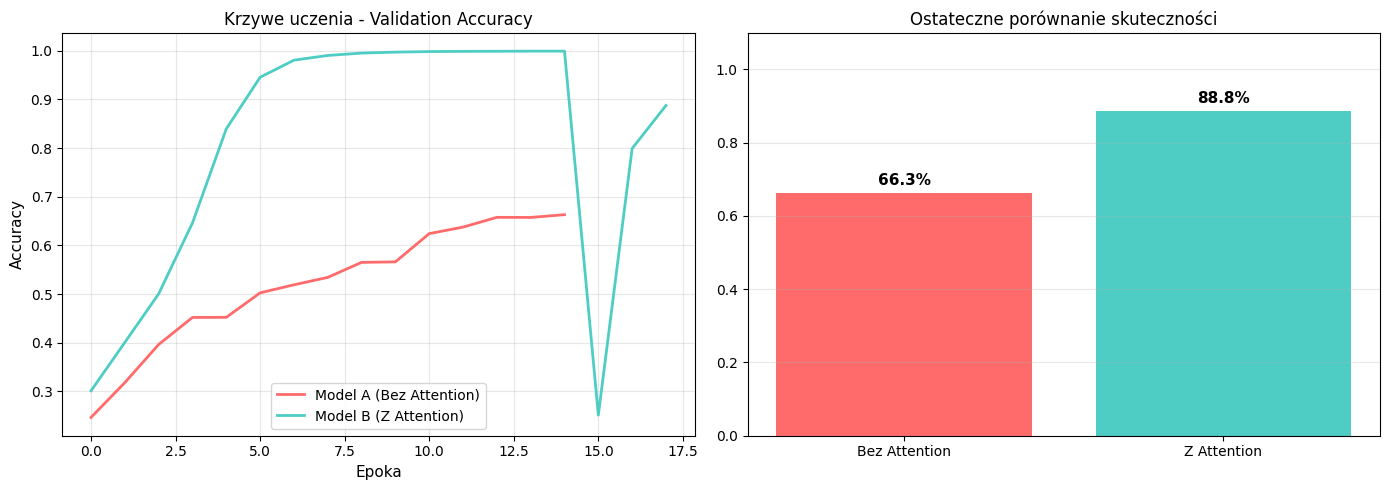

In [6]:

%pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ==========================================
# 1. GENEROWANIE DANYCH (odwracanie sekwencji)
# ==========================================
n_samples = 30000
seq_len = 50 # Długość sekwencji narzucona w zadaniu 9
vocab_size = 11 # Cyfry 0-9 + token specjalny

np.random.seed(42)
# Generowanie losowych sekwencji wejściowych
encoder_input = np.random.randint(1, vocab_size, size=(n_samples, seq_len))

# Decoder input: token START (0) + odwrócona sekwencja
decoder_input = np.zeros((n_samples, seq_len + 1), dtype=np.int32)
decoder_input[:, 1:] = encoder_input[:, ::-1]

# Decoder target: odwrócona sekwencja + token END (0)
decoder_target = np.zeros((n_samples, seq_len + 1), dtype=np.int32)
decoder_target[:, :-1] = encoder_input[:, ::-1]

# ==========================================
# 2. DEFINICJA MODELI (Architektura)
# ==========================================
embed_dim = 64
hidden_units = 128

# --- MODEL A: BEZ ATTENTION ---
enc_inputs_A = layers.Input(shape=(seq_len,))
enc_embed_A = layers.Embedding(vocab_size, embed_dim)(enc_inputs_A)
enc_lstm_A = layers.LSTM(hidden_units, return_state=True)
enc_outputs_A, state_h_A, state_c_A = enc_lstm_A(enc_embed_A)

dec_inputs_A = layers.Input(shape=(seq_len + 1,))
dec_embed_A = layers.Embedding(vocab_size, embed_dim)(dec_inputs_A)
dec_lstm_A = layers.LSTM(hidden_units, return_sequences=True)
dec_outputs_A = dec_lstm_A(dec_embed_A, initial_state=[state_h_A, state_c_A])

dec_dense_A = layers.Dense(vocab_size, activation="softmax")
output_A = dec_dense_A(dec_outputs_A)

model_A = keras.Model([enc_inputs_A, dec_inputs_A], output_A)
model_A.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# --- MODEL B: Z BAHDANAU ATTENTION ---
enc_inputs_B = layers.Input(shape=(seq_len,))
enc_embed_B = layers.Embedding(vocab_size, embed_dim)(enc_inputs_B)
enc_lstm_B = layers.LSTM(hidden_units, return_sequences=True, return_state=True)
enc_outputs_B, state_h_B, state_c_B = enc_lstm_B(enc_embed_B)

dec_inputs_B = layers.Input(shape=(seq_len + 1,))
dec_embed_B = layers.Embedding(vocab_size, embed_dim)(dec_inputs_B)
dec_lstm_B = layers.LSTM(hidden_units, return_sequences=True, return_state=True)
dec_outputs_B, _, _ = dec_lstm_B(dec_embed_B, initial_state=[state_h_B, state_c_B])

# Warstwa AdditiveAttention działa w Kerasie jako implementacja Bahdanau Attention
attention_layer = layers.AdditiveAttention()
context_vector = attention_layer([dec_outputs_B, enc_outputs_B])

# Połączenie (Concatenate) wyjścia dekodera z wektorem kontekstu z Attention
combined = layers.Concatenate()([dec_outputs_B, context_vector])
output_B = layers.Dense(vocab_size, activation="softmax")(combined)

model_B = keras.Model([enc_inputs_B, dec_inputs_B], output_B)
model_B.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ==========================================
# 3. TRENING MODELI Z CALLBACKAMI
# ==========================================
# Konfiguracja Callbacks (zapobieganie overfittingowi)
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5)
]

print(">>> Trenowanie Modelu A (Bez Attention)...")
history_A = model_A.fit(
    [encoder_input, decoder_input], decoder_target,
    batch_size=128, epochs=15, validation_split=0.2,
    callbacks=callbacks_list, verbose=0
)

print(">>> Trenowanie Modelu B (Z Attention)...")
history_B = model_B.fit(
    [encoder_input, decoder_input], decoder_target,
    batch_size=128, epochs=40, validation_split=0.2,
    callbacks=callbacks_list, verbose=0
)

# ==========================================
# 4. WIZUALIZACJA WYNIKÓW
# ==========================================
final_acc_A = history_A.history['val_accuracy'][-1]
final_acc_B = history_B.history['val_accuracy'][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Krzywe uczenia (Accuracy)
axes[0].plot(history_A.history['val_accuracy'], label='Model A (Bez Attention)', color='#ff6b6b', linewidth=2)
axes[0].plot(history_B.history['val_accuracy'], label='Model B (Z Attention)', color='#4ecdc4', linewidth=2)
axes[0].set_title('Krzywe uczenia - Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoka', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Wykres 2: Porównanie końcowe (Bar plot)
bars = axes[1].bar(['Bez Attention', 'Z Attention'], [final_acc_A, final_acc_B], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Ostateczne porównanie skuteczności', fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3, axis='y')

# Dodanie wartości procentowych na słupkach
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                 f"{height:.1%}", ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()